# Embedding Baseline Models

Sanity-check pipeline:
1. Load precomputed DNABERT-2 embeddings (samples × 768)
2. Parse `RiceDiversity_44K_Phenotypes_34traits_PLINK.txt` → **StandardScaler'd numpy array**
3. Align samples between the two by NSFTVID
4. Fit quick baseline models (Ridge, Lasso, RF) on a few traits and report Pearson r

In [4]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# EMB_PATH      = Path("/home/adickson/rice_data/sativas413_embeddings.pt")
# PHENO_PATH    = Path("../rice_data/RiceDiversity_44K_Phenotypes_34traits_PLINK.txt")
EMB_PATH      = Path("/home/andrew.dickson/svar/embeddings/v1/sativas413_embeddings_layer7.pt")
PHENO_PATH    = Path("/home/andrew.dickson/rice_data/RiceDiversity_44K_Phenotypes_34traits_PLINK.txt")

## 1. Load Embeddings
Load the precomputed DNABERT-2 embeddings.

In [5]:
data = torch.load(EMB_PATH, map_location="cpu", weights_only=True)
embeddings  = data["embeddings"].float().numpy()   # (413, 768)
emb_samples = data["sample_ids"]

# # Center embeddings 
# embeddings_centered = embeddings - embeddings.mean(axis=0)

# print(f"Shape (samples × dims) : {embeddings.shape}")
# print(f"First 5 sample IDs: {emb_samples[:5]}")

## 2. Phenotype file → StandardScaler'd numpy array

In [6]:
pheno_raw = pd.read_csv(PHENO_PATH, sep="\t")

TRAIT_COLS = [c for c in pheno_raw.columns if c not in ("HybID", "NSFTVID")]
print(f"{len(TRAIT_COLS)} trait columns.")

# Extract NSFTVID from embedding sample names (suffix after last '_')
emb_nsftvid = [int(s.rsplit("_", 1)[-1]) for s in emb_samples]
emb_id_to_idx = {nid: i for i, nid in enumerate(emb_nsftvid)}

# Keep only phenotype rows that have a matching valid embedding sample
pheno_raw["NSFTVID"] = pheno_raw["NSFTVID"].astype(int)
pheno_matched = pheno_raw[pheno_raw["NSFTVID"].isin(emb_id_to_idx)].copy()
pheno_matched = pheno_matched.reset_index(drop=True)

print(f"Phenotype rows with matching embedding: {len(pheno_matched)} / {len(pheno_raw)}")

# Reorder embeddings rows to match phenotype order
emb_row_order = [emb_id_to_idx[nid] for nid in pheno_matched["NSFTVID"]]
# X = embeddings[emb_row_order, :]   # reordered matrix
X = StandardScaler().fit_transform(embeddings[emb_row_order])


print(f"Aligned X shape: {X.shape}")

# Build the scaled phenotype array
Y_raw = pheno_matched[TRAIT_COLS].values.astype(float)   # (n_samples, n_traits)
Y_scaled = np.full_like(Y_raw, np.nan)
for j in range(Y_raw.shape[1]):
    col = Y_raw[:, j]
    mask = ~np.isnan(col)
    if mask.sum() < 2:
        continue
    mu  = col[mask].mean()
    std = col[mask].std(ddof=0)
    Y_scaled[mask, j] = (col[mask] - mu) / (std if std > 0 else 1.0)

print(f"Y_scaled shape : {Y_scaled.shape}  (samples × traits)")


36 trait columns.
Phenotype rows with matching embedding: 383 / 413
Aligned X shape: (383, 768)
Y_scaled shape : (383, 36)  (samples × traits)


In [7]:
# ── Preprocessing flags ───────────────────────────────────────────────────────
# ── PC1 removal ───────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD

X_proc = StandardScaler().fit_transform(embeddings[emb_row_order])

# X_proc = X - X.mean(axis=0, keepdims=True)
# _svd1 = TruncatedSVD(n_components=1, random_state=42).fit(X_proc)
# print(f"{_svd1.explained_variance_ratio_[:10].round(3)}")

# pc1    = _svd1.components_[0]                       # (768,)
# X_proc -= X_proc.dot(pc1)[:, None] * pc1[None, :]
# X_proc = StandardScaler().fit_transform(X_proc)

In [9]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.decomposition import TruncatedSVD

# Exploratory SVD for UMAP — fitted on X_proc so REMOVE_PC1 is respected
print("Fitting TruncatedSVD (120 components) on embeddings...")
svd = TruncatedSVD(n_components=120, random_state=42)
# X_svd = svd.fit_transform(embeddings - embeddings.mean(axis=0, keepdims=True))   # (n_samples, 120)
X_svd = svd.fit_transform(X_proc)   # (n_samples, 120)

print(f"SVD cumulative variance (20 components): {svd.explained_variance_ratio_.sum():.3f}")
print(f"  PC1: {svd.explained_variance_ratio_[0]:.3f}  "
      f"PC2: {svd.explained_variance_ratio_[1]:.3f}")

print(f"Explained variance ratio (first 10 components): "
      f"{svd.explained_variance_ratio_[:10].round(3)}")
print(f"Total variance explained: {svd.explained_variance_ratio_.sum():.3f}")
X_svd = StandardScaler().fit_transform(X_svd)

Fitting TruncatedSVD (120 components) on embeddings...
SVD cumulative variance (20 components): 0.982
  PC1: 0.297  PC2: 0.143
Explained variance ratio (first 10 components): [0.297 0.143 0.086 0.06  0.042 0.034 0.029 0.027 0.022 0.014]
Total variance explained: 0.982


/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done: (383, 2)


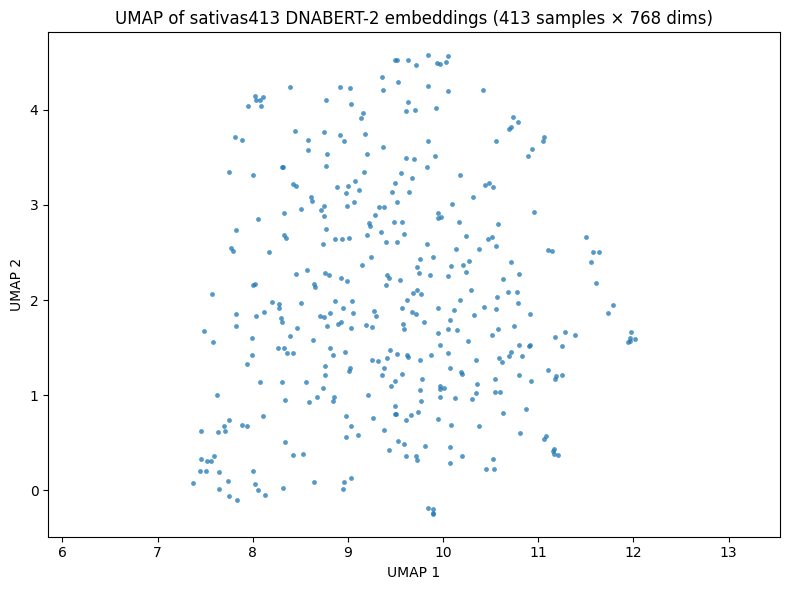

In [10]:
import umap
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
coords  = reducer.fit_transform(X_svd)

print("UMAP done:", coords.shape)
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(coords[:, 0], coords[:, 1], s=12, alpha=0.75, linewidths=0)

ax.set_title("UMAP of sativas413 DNABERT-2 embeddings (413 samples × 768 dims)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_aspect("equal", "datalim")

plt.tight_layout()
plt.show()

## 3. Dimensionality reduction (SVD)
Reduce dimensionality to match the baseline notebook pipeline.

In [ ]:
# from sklearn.decomposition import TruncatedSVD

# print("Fitting TruncatedSVD (120 components) on embeddings...")
# svd   = TruncatedSVD(n_components=120, random_state=42)
# X_svd = svd.fit_transform(X_proc)   # (n_samples, 120)

# if WHITEN:
#     col_std = X_svd.std(axis=0)
#     col_std[col_std == 0] = 1.0
#     X_svd /= col_std
#     print("Whitened: SVD components scaled to unit std")

# print(f"Explained variance ratio (first 10 components): "
#       f"{svd.explained_variance_ratio_[:10].round(3)}")
# print(f"Total variance explained: {svd.explained_variance_ratio_.sum():.3f}")

## 4. Baseline models
Run Ridge, Lasso, and Random Forest on the traits using 5-fold CV. Reports Pearson r and R² on held-out folds.

In [11]:
from scipy.stats import pearsonr
from sklearn.linear_model import RidgeCV, LassoCV, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

N_SVD = 50  # components fitted per fold on training data only

def cv_eval(X_feat, y, models, n_splits=10, random_state=42):
    """K-fold CV with per-fold SVD reduction to avoid leakage."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = {name: {"pearson_r": [], "r2": []} for name, _ in models}

    for train_idx, test_idx in kf.split(X_feat):
        X_tr, X_te = X_feat[train_idx], X_feat[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Fit SVD on training fold only — test fold must not influence the projection
        # svd_fold = TruncatedSVD(n_components=N_SVD, random_state=random_state)
        # X_tr = svd_fold.fit_transform(X_tr)
        # X_te = svd_fold.transform(X_te)

        for name, model in models:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
            r, _ = pearsonr(y_te, y_pred)
            results[name]["pearson_r"].append(r)
            results[name]["r2"].append(r2_score(y_te, y_pred))

    return {
        name: {
            "pearson_r":     np.mean(vals["pearson_r"]),
            "r2":            np.mean(vals["r2"]),
            "n_splits":      n_splits,
            "r2_std":        np.std(vals["r2"]),
            "pearson_r_std": np.std(vals["pearson_r"]),
        }
        for name, vals in results.items()
    }

MODELS = [
    ("Ridge", Ridge(alpha=4.0)),
    ("KNN", KNeighborsRegressor(n_neighbors=5)),
    # ("SVR_linear", SVR(kernel="linear")),
    ("SVR_rbf", SVR(kernel="rbf")),
    # ("RandomForest", RandomForestRegressor(n_estimators=200, min_samples_split=5))
    # ("MLPRegressor", MLPRegressor(hidden_layer_sizes=[1000], ))
]

EVAL_TRAITS = [
    "Alkali spreading value",
    "Amylose content",
    "Panicle number per plant",
    "Protein content",
    "Seed length",
    "Seed number per panicle",
]

all_rows = []
for trait in EVAL_TRAITS:
    t_idx = TRAIT_COLS.index(trait)
    y_t   = Y_scaled[:, t_idx]
    mask  = ~np.isnan(y_t)
    if mask.sum() < 30:
        print(f"Skipping {trait!r} — too few non-NaN samples ({mask.sum()})")
        continue

    res = cv_eval(X_proc[mask], y_t[mask], MODELS)
    for model_name, metrics in res.items():
        all_rows.append({
            "Trait":         trait,
            "Model":         model_name,
            "Pearson r":     round(metrics["pearson_r"], 4),
            "R²":            round(metrics["r2"],        4),
            "R² std":        round(metrics["r2_std"],    4),
            "Pearson r std": round(metrics["pearson_r_std"], 4),
            "n_samples":     int(mask.sum()),
        })


In [12]:
results_df = pd.DataFrame(all_rows)
results_df = results_df.sort_values(["Trait", "Pearson r"], ascending=[True, False])
results_df

,Trait,Model,Pearson r,R²,R² std,Pearson r std,n_samples
2,Alkali spreading value,SVR_rbf,0.5065,0.2288,0.1152,0.1187,374
1,Alkali spreading value,KNN,0.4389,0.1218,0.2344,0.1653,374
0,Alkali spreading value,Ridge,0.3312,-0.4987,0.4226,0.1403,374
5,Amylose content,SVR_rbf,0.7181,0.5047,0.1732,0.1185,372
4,Amylose content,KNN,0.6531,0.3795,0.1542,0.0848,372
3,Amylose content,Ridge,0.6241,0.1057,0.3509,0.1158,372
8,Panicle number per plant,SVR_rbf,0.8062,0.6429,0.0759,0.0488,345
7,Panicle number per plant,KNN,0.7622,0.5675,0.1017,0.0603,345
6,Panicle number per plant,Ridge,0.6365,0.2019,0.1792,0.0716,345
11,Protein content,SVR_rbf,0.4209,0.1432,0.1474,0.1482,364


In [51]:
for trait, subdf in results_df[["Trait", "Model", "Pearson r", "R²", "R² std"]].groupby("Trait"):
    print(f"\nTrait: {trait}")
    print(subdf[["Model", "Pearson r", "R²", "R² std"]].to_string(index=False))


Trait: Alkali spreading value
Model  Pearson r      R²  R² std
  KNN     0.4540  0.1622  0.1475
Ridge     0.1475 -5.3882  6.6516

Trait: Amylose content
Model  Pearson r      R²  R² std
  KNN     0.6252  0.3434  0.1874
Ridge     0.3829 -2.3976  1.8042

Trait: Panicle number per plant
Model  Pearson r      R²  R² std
  KNN     0.7588  0.5525  0.0910
Ridge     0.5469 -0.3019  0.4912

Trait: Protein content
Model  Pearson r      R²  R² std
  KNN     0.2664 -0.0079  0.1655
Ridge     0.1237 -5.5192  6.1976

Trait: Seed length
Model  Pearson r      R²  R² std
  KNN     0.4557  0.0921  0.2360
Ridge     0.3743 -1.0588  0.8071

Trait: Seed number per panicle
Model  Pearson r      R²  R² std
  KNN     0.4182  0.1416  0.0986
Ridge     0.2666 -2.6741  1.5704


In [ ]:
# Heatmap of Pearson r across traits × models
pivot = results_df.pivot(index="Trait", columns="Model", values="Pearson r")
pivot = pivot.dropna(how='all')

fig_height = max(4, int(len(pivot.index) * 0.25))
fig, ax = plt.subplots(figsize=(8, fig_height))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=-0.2, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title("5-fold CV Pearson r (Embedding PCA features, 120 components)")
plt.colorbar(im, ax=ax, label="Pearson r")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()